In [6]:
import os, sys, glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from astropy.coordinates import match_coordinates_sky
from astropy.coordinates import SkyCoord
from astropy.table import Table, Column
from astropy.stats import median_absolute_deviation
import astropy.units as u
from scipy.stats import gaussian_kde
%matplotlib inline

cat_dynrange = '/homes/fdg/storage/surveytgts/analysis/dynrange.txt'
n_groups = 7
dist_min = 30/60. # arcmin, needs to be equal to the one used in the script
dist_max = 630/60. # arcmin, needs to be equal to the one used in the script
step = 60/60    # arcmin, needs to be equal to the one used in the script

tot sources: 12946
1500: Min flux: 20.004654 mJy - Max flux: 27.596274
1500: Min flux: 27.599987 mJy - Max flux: 39.585276
1500: Min flux: 39.588699 mJy - Max flux: 56.591667
1500: Min flux: 56.602316 mJy - Max flux: 85.691753
1499: Min flux: 85.724271 mJy - Max flux: 144.252967
1499: Min flux: 144.371122 mJy - Max flux: 318.417692
1499: Min flux: 318.461270 mJy - Max flux: 4844.669927


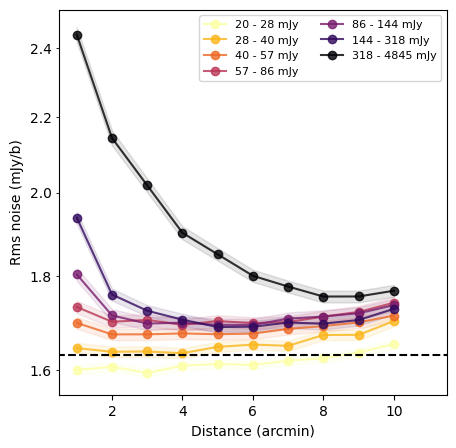

In [10]:
cat_dr = Table.read(cat_dynrange, format='ascii')
print("tot sources: %i" % len(cat_dr))
cat_dr.rename_column('col1','Source_name')
cat_dr.rename_column('col2','Total_flux')
[cat_dr.rename_column('col%i' % (i), 'rms_%i' % (i-2)) for i in range(3,len(cat_dr.colnames)+1)]
cat_dr.sort('Total_flux')
cat_dr = cat_dr[cat_dr['Total_flux']>20]
cat_dr = cat_dr[cat_dr['Total_flux']<5000]

dists = (np.arange(dist_min,dist_max,step)+step/2.) # arcmin, needs to be equal to the one used in the script

fig, ax = plt.subplots(nrows=1, figsize=(5,5))
fig.subplots_adjust(hspace=0)

ax.set_xlabel(r'Distance (arcmin)')
ax.set_ylabel(r'Rms noise (mJy/b)')

#for i in range(1,21):
#    cat_dr['rms_%i' % i] /= cat_dr['rms_20']

colors = plt.cm.inferno_r(np.linspace(0,1,n_groups))  
for s, subset in enumerate(np.array_split(cat_dr,n_groups)):
    min_flux = np.min(subset['Total_flux'])
    max_flux = np.max(subset['Total_flux'])
    print("%i: Min flux: %f mJy - Max flux: %f" % (len(subset), min_flux, max_flux))
    n = len(subset)
    rmss = np.array([np.median(subset['rms_%i' % i]) for i in range(1,len(dists)+1)])*1e3
    # Standard error of the median: sqrt(pi/2) * sigma / sqrt(n), with sigma estimated as 1.4826 * MAD
    rmss_err = np.array([median_absolute_deviation(subset['rms_%i' % i]) for i in range(1,len(dists)+1)])*1e3 * 1.4826 * np.sqrt(np.pi/2) / np.sqrt(n)
    #print(rmss, rmss_err)
    ax.plot(dists, rmss, marker='o', label='%.0f - %.0f mJy' % (min_flux, max_flux), c=colors[s], alpha=.8)
    ax.fill_between(dists, rmss-rmss_err, rmss+rmss_err, color=colors[s], alpha=.1)
    
ax.legend(loc=1, prop={'size': 8}, ncol=2)

#colors = plt.cm.inferno_r(cat_dr['Total_flux']/max(cat_dr['Total_flux']))    
#for s, source in enumerate(cat_dr):
#    ax.plot(dists, [source['rms_%i' % i] for i in range(1,21)], marker='', ls='-', c=colors[s], alpha=.2)
    
ax.plot([dist_min-step,dist_max+step],[1.63,1.63], ls="--", color='k')
ax.set_yscale('log')

# colorbar
#cmap = mpl.cm.inferno_r
#norm = mpl.colors.Normalize(vmin=min(cat_dr['Total_flux']/1e3), vmax=max(cat_dr['Total_flux']/1e3))
#cbaxes = fig.add_axes([0.35, 0.7, 0.5, 0.05])
#fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbaxes, label=r'Flux density', format='$%.0f$', orientation='horizontal')
#cbaxes.xaxis.tick_bottom()
#cbaxes.xaxis.set_label_position('top')

from matplotlib import ticker as mticker
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(mticker.ScalarFormatter())

ax.set_xlim(xmin=step/2,xmax=dist_max+step)
#ax.set_ylim(ymin=0.8,ymax=5)

#ax.grid(alpha=.2)

fig.savefig('/homes/fdg/storage/surveytgts/analysis/dynrange.png', bbox_inches='tight')
